In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical, plot_model
import os

import warnings
warnings.filterwarnings("ignore")

In [3]:
data = []
result = []


for r, d, f in os.walk("D:\skincancer\Skin_Data\Cancer"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(r, file)

            img = Image.open(path)
            img = img.resize((128, 128))
            img = np.array(img) / 255.0   # 🔥 normalization

            if img.shape == (128, 128, 3):
                data.append(img)
                result.append([0, 1]) 

In [4]:
for r, d, f in os.walk("D:\\skincancer\\Skin_Data\\Non_Cancer"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(r, file)

            img = Image.open(path)
            img = img.resize((128, 128))
            img = np.array(img) / 255.0

            if img.shape == (128, 128, 3):
                data.append(img)
                result.append([1, 0])

In [5]:
data = np.array(data)
result = np.array(result)

print("Data shape:", data.shape)      
print("Result shape:", result.shape)

Data shape: (288, 128, 128, 3)
Result shape: (288, 2)


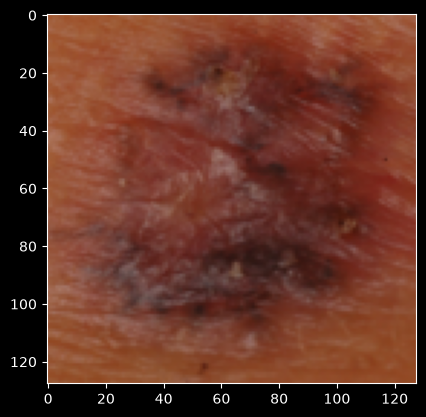

In [6]:
plt.imshow(data[10])

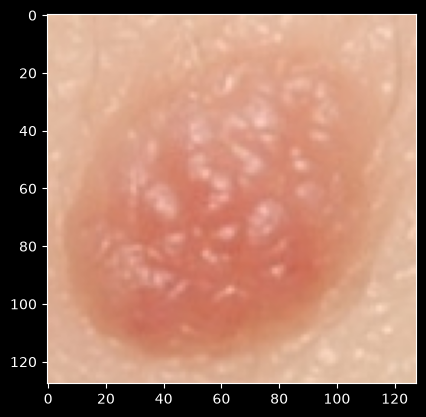

In [7]:
plt.imshow(data[203])

In [8]:
x_train, x_test, y_train, y_test = train_test_split(data, result, test_size=0.2, shuffle=True, random_state=42)

In [9]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), padding='same'))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,621,922 (128.26 MB)

 Trainable params: 33,621,730 (128.26 MB)

 Non-trainable params: 192 (768.00 B)

None


In [10]:
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [11]:
x_train.shape

(230, 128, 128, 3)

In [12]:
y_train.shape

(230, 2)

In [13]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    verbose=1,
    validation_data=(x_test, y_test))

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 80s 20s/step - accuracy: 0.6565 - loss: 41.9751 - val_accuracy: 0.7414 - val_loss: 2.0241
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 75s 17s/step - accuracy: 0.6304 - loss: 10.3899 - val_accuracy: 0.8103 - val_loss: 0.6030
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 47s 11s/step - accuracy: 0.7130 - loss: 3.3814 - val_accuracy: 0.7414 - val_loss: 0.7372
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 7s/step - accuracy: 0.8000 - loss: 1.8168 - val_accuracy: 0.7759 - val_loss: 0.8700
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 7s/step - accuracy: 0.7696 - loss: 1.2273 - val_accuracy: 0.7759 - val_loss: 1.2712
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.8043 - loss: 0.6894 - val_accuracy: 0.6379 - val_loss: 2.2835
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.8522 - loss: 0.4838 - val_accuracy: 0.6552 - val_loss: 2.3921
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.8348 - loss: 0.4740 - val_accuracy: 0.7069 - val_loss: 2.1036
Epo

In [14]:
score = model.evaluate(x_test, y_test, batch_size=64)
print("\nTest accuracy: %.1f%%" % (100.0 * score[1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7414 - loss: 3.2693

Test accuracy: 74.1%


In [15]:
img_path = r"D:\skincancer\Skin_Data\Cancer\Testing\2241-02.JPG"
img = Image.open(img_path)
img = img.resize((128,128))
img = np.array(img) / 255.0   # 🔥 same preprocessing

img = np.expand_dims(img, axis=0)  # shape (1,128,128,3)

prediction = model.predict(img)
pred_class = np.argmax(prediction)

if pred_class == 0:
    print("Prediction: Cancer")
else:
    print("Prediction:  Non Cancer")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step
Prediction: Cancer
